In [ ]:
# input
rep_info_file = "../../data/repId-numPro-numPredPro-numResi-numPredResi-numAnnoPro-isAnno.tsv"
# output
fig_file = "./fig/pred_consistency_seq_cluster.pdf"

In [2]:
import pandas as pd
import tqdm

df_rep = pd.read_table(rep_info_file, header=None, names=["rep_id", "num_protein", "num_pred_protein", "num_residue", "num_pred_residue", "num_anno_pro", "is_anno"])

bins = []
bins.append([1,1])
for i in range(1, 10):
    bins.append([2 ** i, 2 ** (i + 1) - 1])
bins.append([2 ** 10, df_rep['num_protein'].max().item()])
def get_bin_idx(n_member):
    cur_bin_idx = None
    for idx, bin in enumerate(bins):
        lower, upper = bin
        if n_member >= lower and n_member <= upper:
            cur_bin_idx = idx
    assert cur_bin_idx != None
    return cur_bin_idx

df_rep['bin_idx'] = df_rep["num_protein"].map(lambda x: get_bin_idx(x))

data = []
for (idx, ), df_idx in tqdm.tqdm(df_rep.groupby(["bin_idx"])):
    data.append({
        "bin_idx": idx,
        "num_protein": df_idx['num_protein'].sum(),
        "num_pred_protein": df_idx['num_pred_protein'].sum(),
        "num_residue": df_idx['num_residue'].sum(),
        "num_pred_residue": df_idx['num_pred_residue'].sum()
    })
df = pd.DataFrame(data)

df['size_ratio'] = df['num_protein'] / df['num_protein'].sum()
df['protein_pred_ratio'] = df['num_pred_protein'] / df['num_protein']
df['residue_pred_ratio'] = df['num_pred_residue'] / df['num_residue']
df['num_pred_protein'].sum() / df['num_protein'].sum()
df['num_pred_residue'].sum() / df['num_residue'].sum()

100%|██████████| 11/11 [00:00<00:00, 16.55it/s]


np.float64(0.8323894742737333)

np.float64(0.7837680347894426)

In [3]:
df

,bin_idx,num_protein,num_pred_protein,num_residue,num_pred_residue,size_ratio,protein_pred_ratio,residue_pred_ratio
0,0,4191128,4191128,24129356,24129356,0.090943,1.000000,1.000000
1,1,3894531,3618341,23033850,20960614,0.084507,0.929083,0.909992
2,2,3929677,3517158,23323643,20122553,0.085269,0.895025,0.862753
3,3,4001531,3507237,23318513,19512240,0.086829,0.876474,0.836770
4,4,4250175,3662740,24435951,20026639,0.092224,0.861786,0.819556
5,5,4396429,3714647,24908993,19776272,0.095397,0.844924,0.793941
6,6,4430050,3631708,25743480,19576608,0.096127,0.819789,0.760449
7,7,4457668,3523666,26030435,18810553,0.096726,0.790473,0.722637
8,8,4308902,3341886,24956906,17478697,0.093498,0.775577,0.700355
9,9,3450503,2642114,19245953,13021953,0.074872,0.765719,0.676607


([<matplotlib.axis.YTick at 0x7630102dd350>,
 [Text(0, 0.5, '0.5'),
  Text(0, 0.6, '0.6'),
  Text(0, 0.7, '0.7'),
  Text(0, 0.8, '0.8'),
  Text(0, 0.9, '0.9'),
  Text(0, 1.0, '1.0')])

Text(0, 0.5, 'Matched percentage')

Text(0.5, 0, 'Cluster size range')

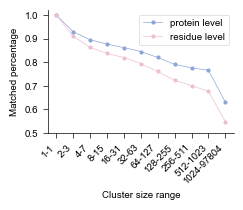

In [4]:
import matplotlib.pyplot as plt
import numpy as np

plt.style.use(f"{PROJECT_DIR}/asset/metalnet.mplstyle")

fig, ax = plt.subplots(figsize=(2.4, 1.6))
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.set_xticks(df['bin_idx'], ["-".join([str(j) for j in bins[i]]) for i in df['bin_idx']], rotation=45, ha='right')

# plt.plot(df['bin_idx'], df['size_ratio'], markersize=4, marker='o')
plt.plot(df['bin_idx'], df['protein_pred_ratio'], markersize=2, marker='o')
plt.plot(df['bin_idx'], df['residue_pred_ratio'], markersize=2, marker='o')
plt.yticks(np.linspace(0.5, 1.0, 6))

plt.ylabel("Matched percentage")
plt.xlabel("Cluster size range")
plt.legend(
    labels=[# 'total protein',
            'protein level',
            'residue level'],
    loc='upper right',
    bbox_to_anchor=(1,1)
)

fig.savefig(fig_file, bbox_inches="tight", transparent=True)